Roll No: 24BAD112
Name: SIVASAKTHI S
Training model with sigmoid activation...
Training model with tanh activation...
Training model with relu activation...


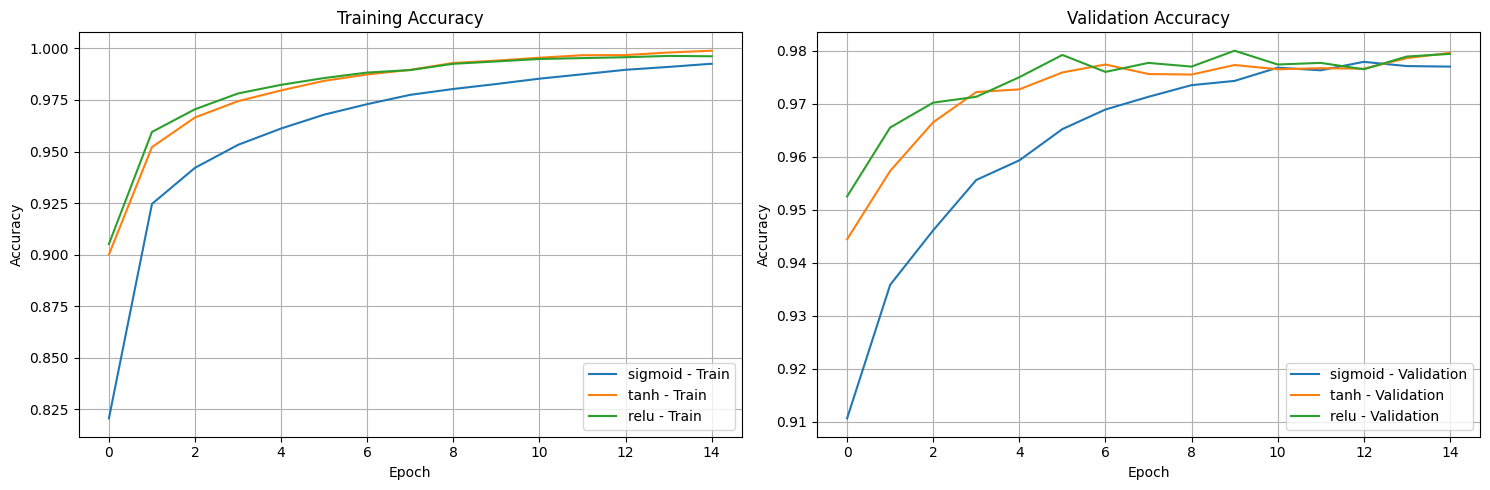

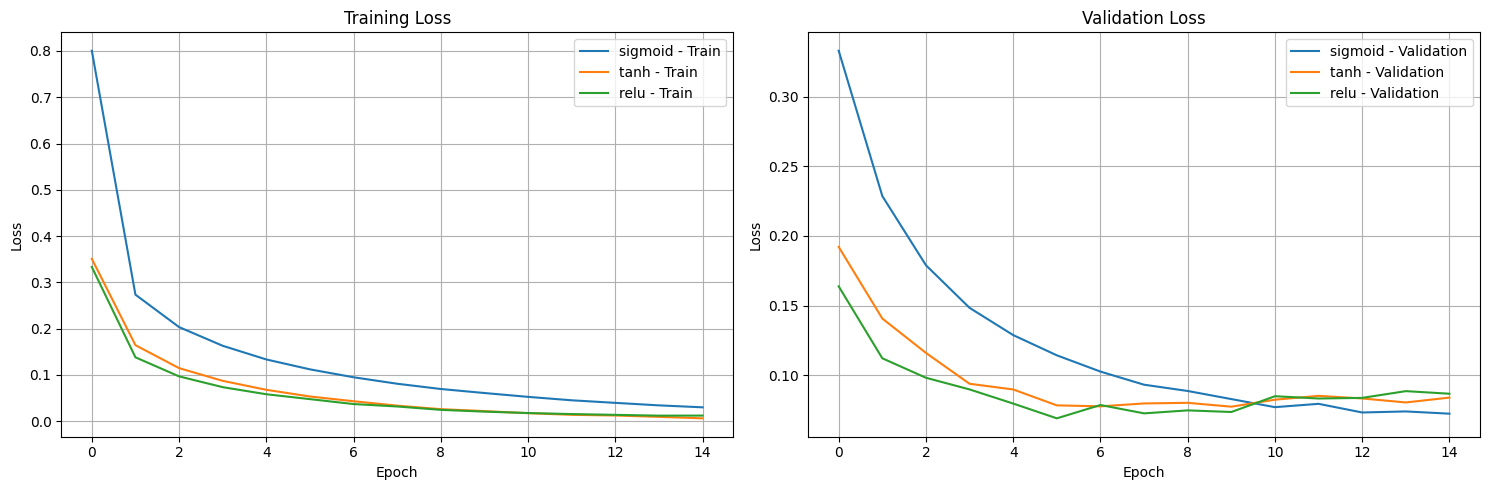


Final Performance Comparison
--------------------------------------------------------------------------------
Activation  Train Acc   Val Acc     Train Loss  Val Loss    
--------------------------------------------------------------------------------
sigmoid     0.9926      0.9770      0.0299      0.0723      
tanh        0.9989      0.9796      0.0061      0.0839      
relu        0.9962      0.9794      0.0121      0.0866      


In [ ]:
print("Roll No: 24BAD112")
print("Name: SIVASAKTHI S")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess the data
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

# Function to build and train model
def build_and_train(activation_name, epochs=15):
    model = keras.Sequential([
        keras.Input(shape=(784,)),
        layers.Dense(128, activation=activation_name),
        layers.Dense(64, activation=activation_name),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=128,
        verbose=0
    )

    return history

# Activation functions to compare
activations = ['sigmoid', 'tanh', 'relu']
histories = {}

# Train models
for act in activations:
    print(f"Training model with {act} activation...")
    histories[act] = build_and_train(act)

# ----------------------------
# Plot Accuracy
# ----------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(histories[act].history['accuracy'], label=f'{act} - Train')

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(histories[act].history['val_accuracy'], label=f'{act} - Validation')

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot Loss
# ----------------------------
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
for act in activations:
    plt.plot(histories[act].history['loss'], label=f'{act} - Train')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for act in activations:
    plt.plot(histories[act].history['val_loss'], label=f'{act} - Validation')

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------
# Final Performance Comparison
# ----------------------------
print("\nFinal Performance Comparison")
print("-" * 80)

print("{:<12}{:<12}{:<12}{:<12}{:<12}".format(
    "Activation",
    "Train Acc",
    "Val Acc",
    "Train Loss",
    "Val Loss"
))

print("-" * 80)

for act in activations:
    h = histories[act].history
    print("{:<12}{:<12.4f}{:<12.4f}{:<12.4f}{:<12.4f}".format(
        act,
        h['accuracy'][-1],
        h['val_accuracy'][-1],
        h['loss'][-1],
        h['val_loss'][-1]
    ))